In [1]:
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)

X_train, X_test, y_train, y_test = train_test_split(mnist.data, mnist.target, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.astype('int32')
y_test = y_test.astype('int32')

# Build the model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.2)

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)

Epoch 1/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8792 - loss: 0.4454 - val_accuracy: 0.9104 - val_loss: 0.3774
Epoch 2/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9165 - loss: 0.3199 - val_accuracy: 0.9151 - val_loss: 0.4181
Epoch 3/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9219 - loss: 0.2920 - val_accuracy: 0.9189 - val_loss: 0.4568
Epoch 4/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9252 - loss: 0.2729 - val_accuracy: 0.9159 - val_loss: 0.4988
Epoch 5/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9263 - loss: 0.2642 - val_accuracy: 0.9158 - val_loss: 0.5321
Epoch 6/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9286 - loss: 0.2572 - val_accuracy: 0.9154 - val_loss: 0.5646
Epoch 7/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9302 - loss: 0.2509 - val_accuracy: 0.9187 - val_loss: 0.5909
Epoch 8/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9309 - loss: 0.2474 - 

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

data = pd.read_csv('MonthlyCoalConsumption.csv')
values = np.array(data['Value'])
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values.reshape(-1, 1))

window_size = 12
X = []
y = []
for i in range(len(scaled_values) - window_size):
    X.append(scaled_values[i:i + window_size])
    y.append(scaled_values[i + window_size])
X = np.array(X)
y = np.array(y)


In [3]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window_size, 1)),
    tf.keras.layers.SimpleRNN(units=32, activation='tanh'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=50, batch_size=16)

loss = model.evaluate(X_test, y_test)
print('Test loss:', loss)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3152
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0775
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1080
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0833
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0547
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0544
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0497
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0401
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0354
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0342
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0320
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0288
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0277
Epoch 14/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0269
Epoch 15/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0258
Epoch 16/50
4/4 ━━━━━━━━━━━━━━━━━━

In [4]:
future_months = 12
last_window = scaled_values[-window_size:].reshape(1, window_size, 1)
predicted_values = []
for _ in range(future_months):
    prediction = model.predict(last_window)
    predicted_values.append(prediction[0][0])
    last_window = np.append(last_window[:, 1:, :], prediction.reshape(1, 1, 1), axis=1)
predicted_values = scaler.inverse_transform(np.array(predicted_values).reshape(-1, 1))
print('Predicted values for the next 12 months: ', predicted_values.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted values for the next 12 months:  [51458.617 49880.76  42548.24  33570.918 30526.775 36977.75  44820.832
 40175.1   35534.094 27767.07  28553.67  35369.05 ]


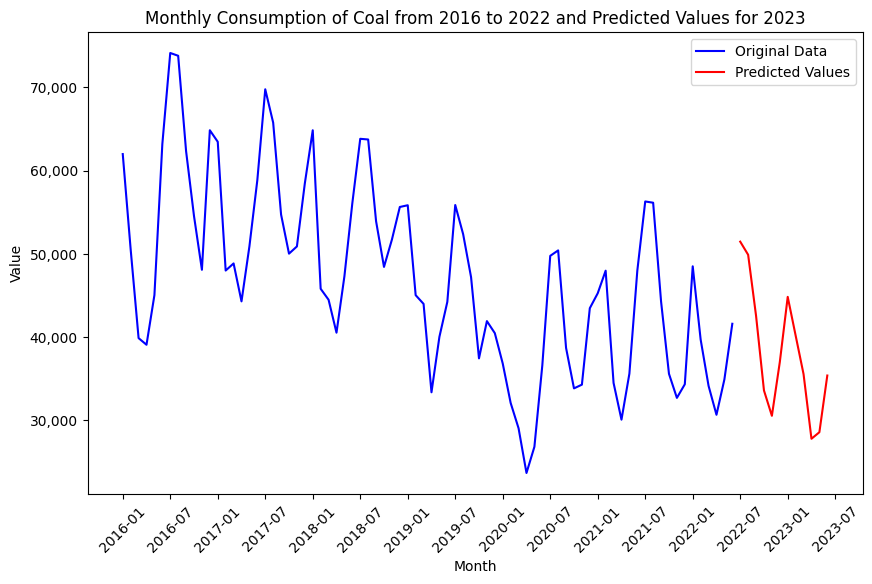

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator ## for graph formatting
from matplotlib.ticker import FuncFormatter ## for formatting y-axis
    
# Function to format the Y-axis values
def y_format(value, tick_number):
    return f'{value:,.0f}'
    
# Plot original time series data and predicted values
plt.figure(figsize=(10, 6))
plt.plot(data['Month'], data['Value'], label='Original Data', color='blue')
plt.plot(range(len(data['Value']), len(data['Value']) + future_months), predicted_values, label='Predicted Values', color='red')
    
# Create a list for the months
pd_months = pd.date_range(start='2016-01-01', end='2023-07-01', freq='MS')
    
xticks_positions = range(0, len(pd_months), 6) # Positions to display ticks (e.g., every 12 months)
xticks_labels = [pd_months[pos].strftime('%Y-%m') for pos in xticks_positions] # Labels corresponding to positions
    
plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Monthly Consumption of Coal from 2016 to 2022 and Predicted Values for 2023')
plt.legend()
plt.xticks(ticks=xticks_positions, labels=xticks_labels, rotation=45)
# Apply the formatter to the Y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(y_format))
    
plt.show()
    


In [6]:
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mnist = fetch_openml('mnist_784', version=1)
X_train, X_test, y_train, y_test = train_test_split(mnist.data, mnist.target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.astype('int32')
y_test = y_test.astype('int32')

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)

Epoch 1/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9265 - loss: 0.2494 - val_accuracy: 0.9543 - val_loss: 0.1622
Epoch 2/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9681 - loss: 0.1042 - val_accuracy: 0.9620 - val_loss: 0.1559
Epoch 3/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9776 - loss: 0.0726 - val_accuracy: 0.9615 - val_loss: 0.1668
Epoch 4/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9840 - loss: 0.0493 - val_accuracy: 0.9618 - val_loss: 0.1811
Epoch 5/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9857 - loss: 0.0437 - val_accuracy: 0.9661 - val_loss: 0.1704
Epoch 6/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9888 - loss: 0.0357 - val_accuracy: 0.9629 - val_loss: 0.2168
Epoch 7/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9902 - loss: 0.0307 - val_accuracy: 0.9669 - val_loss: 0.1825
Epoch 8/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9902 - loss: 0.0321 - 

In [12]:
rank2_tensor = tf.Variable([['test', 'ok'], ['test', 'yes']], tf.string)

In [8]:
tf.rank(rank2_tensor)

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [10]:
rank2_tensor.shape

TensorShape([2, 2])